In [1]:
import numpy as np
import pandas as pd 


In [2]:
data = pd.read_csv("loan-test.csv")
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [3]:
data.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [4]:
encode_data=data[["Gender","Married"]]
encode_data


,Gender,Married
0,Male,Yes
1,Male,Yes
2,Male,Yes
3,Male,Yes
4,Male,No
...,...,...
362,Male,Yes
363,Male,Yes
364,Male,No
365,Male,Yes


In [5]:
encode_data.isnull().sum()

Gender     11
Married     0
dtype: int64

In [6]:
encode_data["Gender"].fillna(encode_data["Gender"].mode()[0],inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_19576\1242494136.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  encode_data["Gender"].fillna(encode_data["Gender"].mode()[0],inplace=True)
C:\Users\Asus\AppData\Local\Temp\ipykernel_19576\1242494136.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  encode_data["Gender"].fillna(encode_data["Gend

In [7]:
pd.get_dummies(encode_data) # now the dats is encoded , we have used the pythin in build function for that is pd.get_dummies .

,Gender_Female,Gender_Male,Married_No,Married_Yes
0,False,True,False,True
1,False,True,False,True
2,False,True,False,True
3,False,True,False,True
4,False,True,True,False
...,...,...,...,...
362,False,True,False,True
363,False,True,False,True
364,False,True,True,False
365,False,True,False,True


In [8]:
pd.get_dummies(encode_data).info() # thus we have get the data in the boolen format but we want in the numerical format  therfore we used the sklean libary 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Gender_Female  367 non-null    bool 
 1   Gender_Male    367 non-null    bool 
 2   Married_No     367 non-null    bool 
 3   Married_Yes    367 non-null    bool 
dtypes: bool(4)
memory usage: 1.6 KB


In [9]:
from sklearn.preprocessing import OneHotEncoder

In [10]:
ohe=OneHotEncoder(drop='first')
ar =ohe.fit_transform(encode_data).toarray()

In [ ]:
pd.DataFrame(ar,columns=["Gender_Male","Married_yes"])  

,Gender_Male,Married_yes
0,1.0,1.0
1,1.0,1.0
2,1.0,1.0
3,1.0,1.0
4,1.0,0.0
...,...,...
362,1.0,1.0
363,1.0,1.0
364,1.0,0.0
365,1.0,1.0


In [12]:
#Label Encoding

In [13]:
df= pd.DataFrame({"name":["Prathamesh","Apurva","cow","goat","Machine Learning"]})
df

,name
0,Prathamesh
1,Apurva
2,cow
3,goat
4,Machine Learning


In [14]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
df["en_name"]=le.fit_transform(df["name"]) 

In [16]:
df

,name,en_name
0,Prathamesh,2
1,Apurva,0
2,cow,3
3,goat,4
4,Machine Learning,1


In [17]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [18]:
la=LabelEncoder()
la.fit(data["Property_Area"])

LabelEncoder()

In [19]:
data["Property_Area"].unique()

array(['Urban', 'Semiurban', 'Rural'], dtype=object)

In [20]:
la.transform(data["Property_Area"]) 

array([2, 2, 2, 2, 2, 2, 1, 0, 2, 1, 2, 1, 2, 1, 1, 2, 2, 1, 2, 1, 2, 2,
       2, 2, 2, 0, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 1,
       2, 2, 2, 1, 2, 1, 2, 1, 1, 2, 2, 2, 0, 1, 1, 1, 1, 2, 1, 0, 2, 1,
       1, 1, 1, 0, 1, 1, 2, 0, 1, 2, 2, 0, 1, 2, 2, 2, 0, 0, 1, 0, 2, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 2, 1, 2, 1, 0, 1, 2, 0, 1, 1, 2, 0, 1, 2,
       1, 1, 2, 1, 0, 1, 1, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 2, 2, 1, 2, 0,
       0, 2, 2, 2, 0, 0, 1, 1, 0, 0, 2, 1, 0, 2, 1, 0, 1, 2, 2, 2, 0, 2,
       0, 1, 2, 0, 1, 0, 0, 1, 2, 0, 0, 1, 2, 2, 1, 0, 0, 0, 0, 2, 0, 0,
       2, 0, 0, 2, 1, 1, 2, 0, 2, 1, 1, 1, 0, 0, 0, 2, 0, 0, 1, 2, 1, 0,
       2, 0, 0, 2, 2, 1, 1, 1, 1, 1, 2, 0, 2, 0, 1, 0, 0, 2, 1, 0, 0, 2,
       2, 0, 2, 0, 1, 2, 2, 0, 0, 2, 1, 2, 0, 1, 2, 2, 1, 0, 1, 2, 2, 1,
       1, 0, 1, 1, 2, 2, 1, 0, 2, 1, 1, 2, 2, 0, 0, 2, 0, 0, 1, 1, 0, 0,
       0, 1, 2, 0, 0, 0, 2, 0, 1, 1, 1, 1, 2, 1, 1, 1, 1, 0, 2, 0, 2, 2,
       0, 0, 2, 2, 1, 2, 0, 2, 2, 1, 1, 0, 1, 0, 2,

In [21]:
# ordinal encoding 

In [22]:
df = pd.DataFrame({"Size":["s","m","xl","xxl","s","m","xl","xl","xxl","s","m","s"]})
df.head(4)

,Size
0,s
1,m
2,xl
3,xxl


In [23]:
ord_data=[["s","m","xl","xxl"]]

In [24]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder(categories=ord_data)
df["en_Size"]=oe.fit_transform(df[["Size"]])

In [25]:
df

,Size,en_Size
0,s,0.0
1,m,1.0
2,xl,2.0
3,xxl,3.0
4,s,0.0
5,m,1.0
6,xl,2.0
7,xl,2.0
8,xxl,3.0
9,s,0.0


In [26]:
data1=pd.read_csv("loan-test.csv")
data1.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [27]:
data1["Property_Area"].unique()


array(['Urban', 'Semiurban', 'Rural'], dtype=object)

In [28]:
ord_data1=[["Rural","Semiurban","Urban"]]
from sklearn.preprocessing import OrdinalEncoder


In [29]:
oen= OrdinalEncoder(categories=ord_data1)
data1["Property_Area"]=oen.fit_transform(data1[["Property_Area"]])


In [30]:
data1.tail(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,2.0
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,2.0
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,1.0
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,0.0
366,LP002989,Male,No,0,Graduate,Yes,9200,0,98.0,180.0,1.0,0.0


In [31]:
#outliers

In [32]:
import seaborn as sns   # to identify the outliers
import matplotlib.pyplot as plt

In [33]:
data_outlier =data
data_outlier.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban


In [34]:
data_outlier.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [35]:
data_outlier.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


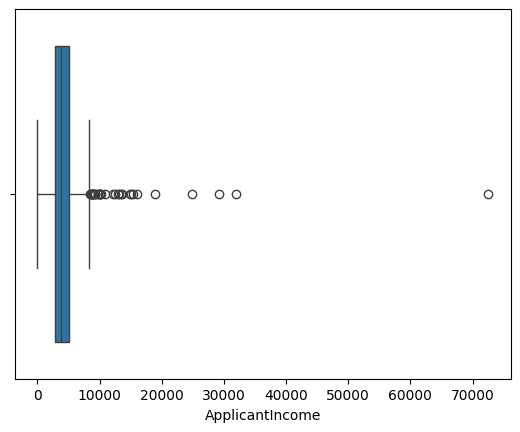

In [36]:
sns.boxplot(x="ApplicantIncome",data=data_outlier)  
plt.show()

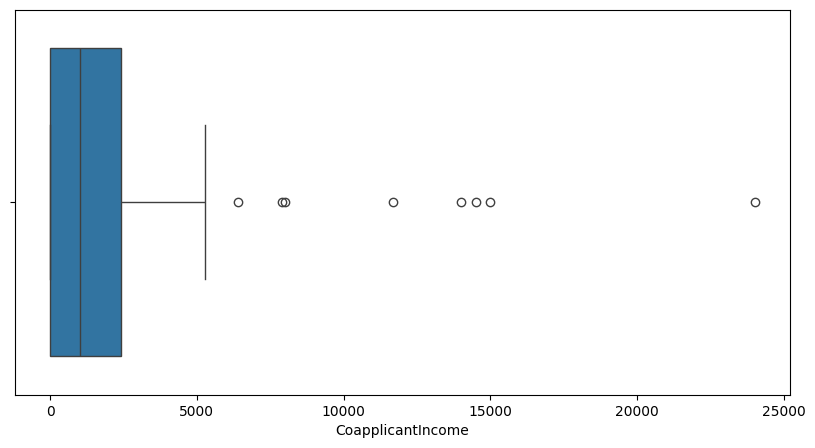

In [37]:
plt.figure(figsize=(10,5))
sns.boxplot(x="CoapplicantIncome",data=data_outlier)
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_19576\3082982415.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_outlier["ApplicantIncome"])


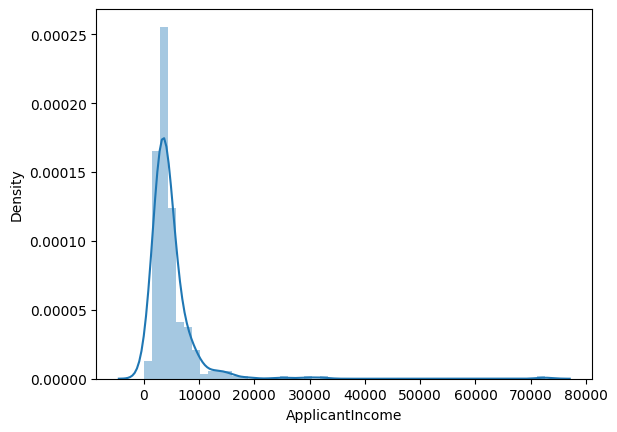

In [38]:
# we can also displot to detect outlieres , which can be identified using the tail
sns.distplot(data_outlier["ApplicantIncome"])
plt.show()

In [39]:
 # to remove outlier using IQR

In [40]:
data_outlier.shape

(367, 12)

In [41]:
data_outlier.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


In [42]:
q1=data_outlier["CoapplicantIncome"].quantile(0.25)
q3=data_outlier["CoapplicantIncome"].quantile(0.75)
q1,q3

(np.float64(0.0), np.float64(2430.5))

In [43]:
IQR=q3-q1
IQR

np.float64(2430.5)

In [44]:
min_range=q1-(1.5*IQR)
max_range = q3+(1.5*IQR)
min_range , max_range

(np.float64(-3645.75), np.float64(6076.25))

In [45]:
data_outlier.shape

(367, 12)

In [46]:
new_data_outliers=data_outlier[data_outlier["CoapplicantIncome"]<=max_range]

In [47]:
new_data_outliers.shape  # no outliers are present in this coloums 

(359, 12)

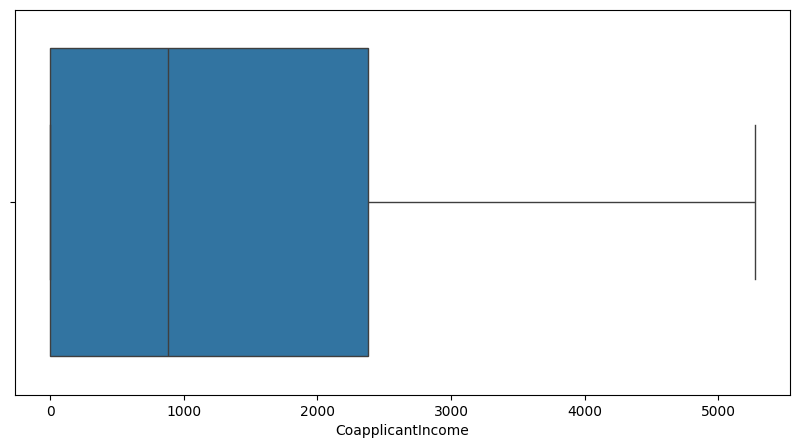

In [48]:
plt.figure(figsize=(10,5))
sns.boxplot(x="CoapplicantIncome",data=new_data_outliers)
plt.show()  # no outliers are present in this.

In [49]:
 # remove outlier using the Z - score 

In [50]:
new_data_outliers.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       28
Property_Area         0
dtype: int64

In [51]:
new_data_outliers.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,359.000000,359.000000,354.000000,353.000000,331.000000
mean,4774.189415,1321.863510,134.872881,342.651558,0.827795
std,4912.752831,1457.181567,58.816690,65.274380,0.378131
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2871.500000,0.000000,100.000000,360.000000,1.000000
50%,3785.000000,879.000000,125.000000,360.000000,1.000000
75%,5020.500000,2378.000000,157.750000,360.000000,1.000000
max,72529.000000,5272.000000,550.000000,480.000000,1.000000


In [52]:
Z_score=new_data_outliers["CoapplicantIncome"]-(new_data_outliers["CoapplicantIncome"].mean())/(new_data_outliers["CoapplicantIncome"].std())

new_data_outliers["Z_Score"] = Z_score

C:\Users\Asus\AppData\Local\Temp\ipykernel_19576\2268626140.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data_outliers["Z_Score"] = Z_score


In [53]:
new_data_outliers.shape

(359, 13)

In [54]:
new_data_outliers[new_data_outliers["Z_Score"]>3]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Z_Score
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban,1499.092863
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban,1799.092863
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban,2545.092863
5,LP001054,Male,Yes,0,Not Graduate,Yes,2165,3422,152.0,360.0,1.0,Urban,3421.092863
9,LP001067,Male,No,0,Not Graduate,No,2400,2400,123.0,360.0,1.0,Semiurban,2399.092863
...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,LP002969,Male,Yes,1,Graduate,No,2269,2167,99.0,360.0,1.0,Semiurban,2166.092863
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban,1776.092863
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban,708.092863
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban,1992.092863


In [55]:
#by appling the normal method to remove outliers

In [56]:
min_range_nor=new_data_outliers["CoapplicantIncome"].mean()-(3*new_data_outliers["CoapplicantIncome"].std())

max_range_nor=new_data_outliers["CoapplicantIncome"].mean()+(3*new_data_outliers["CoapplicantIncome"].std())

min_range_nor,max_range_nor

(np.float64(-3049.68119020619), np.float64(5693.408209704797))

In [57]:
new_data_by_nor_outlier_method=new_data_outliers[new_data_outliers["CoapplicantIncome"]<=max_range_nor]

new_data_by_nor_outlier_method.shape

(359, 13)